In [1]:
!pip install graphviz

In [ ]:
from graphviz import Digraph

dot = Digraph("Cross_Attention_Model", format="png")

dot.attr(rankdir="LR", bgcolor="white")

# Styles
conv_style = {'shape': 'box', 'style': 'filled', 'color': '#c7ddf5', 'fontsize': '12'}
fc_style   = {'shape': 'box', 'style': 'filled', 'color': '#c8e6c9', 'fontsize': '12'}
special_style = {'shape': 'box', 'style': 'filled', 'color': '#ffe0b2', 'fontsize': '12'}
output_style  = {'shape': 'box', 'style': 'filled', 'color': '#f8cccc', 'fontsize': '12'}

# Encoder 1 (top row)
dot.node("in1", "Input 1", **special_style)
dot.node("c1_1", "Conv Block 1 (32)\nBN + ReLU + MaxPool", **conv_style)
dot.node("c1_2", "Conv Block 2 (64)\nBN + ReLU + MaxPool", **conv_style)
dot.node("c1_3", "Conv Block 3 (128)\nBN + ReLU + MaxPool", **conv_style)
dot.node("c1_4", "Conv Block 4 (256)\nBN + ReLU + MaxPool", **conv_style)
dot.node("e1",   "FC Embedding (256)\nBN + Dropout", **fc_style)

dot.edges([
    ("in1", "c1_1"),
    ("c1_1", "c1_2"),
    ("c1_2", "c1_3"),
    ("c1_3", "c1_4"),
    ("c1_4", "e1")
])

# Encoder 2 (bottom row)
dot.node("in2", "Input 2", **special_style)
dot.node("c2_1", "Conv Block 1 (32)\nBN + ReLU + MaxPool", **conv_style)
dot.node("c2_2", "Conv Block 2 (64)\nBN + ReLU + MaxPool", **conv_style)
dot.node("c2_3", "Conv Block 3 (128)\nBN + ReLU + MaxPool", **conv_style)
dot.node("c2_4", "Conv Block 4 (256)\nBN + ReLU + MaxPool", **conv_style)
dot.node("e2",   "FC Embedding (256)\nBN + Dropout", **fc_style)

dot.edges([
    ("in2", "c2_1"),
    ("c2_1", "c2_2"),
    ("c2_2", "c2_3"),
    ("c2_3", "c2_4"),
    ("c2_4", "e2")
])

# Cross Attention
dot.node("attn", "Cross-Attention\n(MultiHead f1 ↔ f2)", **special_style)
dot.edge("e1", "attn")
dot.edge("e2", "attn")

dot.node("attn12", "attn12", **special_style)
dot.node("attn21", "attn21", **special_style)

dot.edge("attn", "attn12")
dot.edge("attn", "attn21")

# Difference
dot.node("diff", "|attn12 - attn21|\nAbsolute Difference", **special_style)
dot.edge("attn12", "diff")
dot.edge("attn21", "diff")

# Concatenate
dot.node("concat", "Concatenate\n[attn12, attn21, diff]", **special_style)
dot.edges([
    ("attn12", "concat"),
    ("attn21", "concat"),
    ("diff", "concat")
])

# Classifier
dot.node("fc1", "Dense(124)\nBN + Dropout", **fc_style)
dot.node("fc2", "Dense(64)\nBN + Dropout", **fc_style)
dot.node("out", "Dense(1)\nSigmoid", **output_style)

dot.edge("concat", "fc1")
dot.edge("fc1", "fc2")
dot.edge("fc2", "out")

# Save
dot.render("horizontal_cross_attention_diagram", cleanup=True)
print("Generated: horizontal_cross_attention_diagram.png")


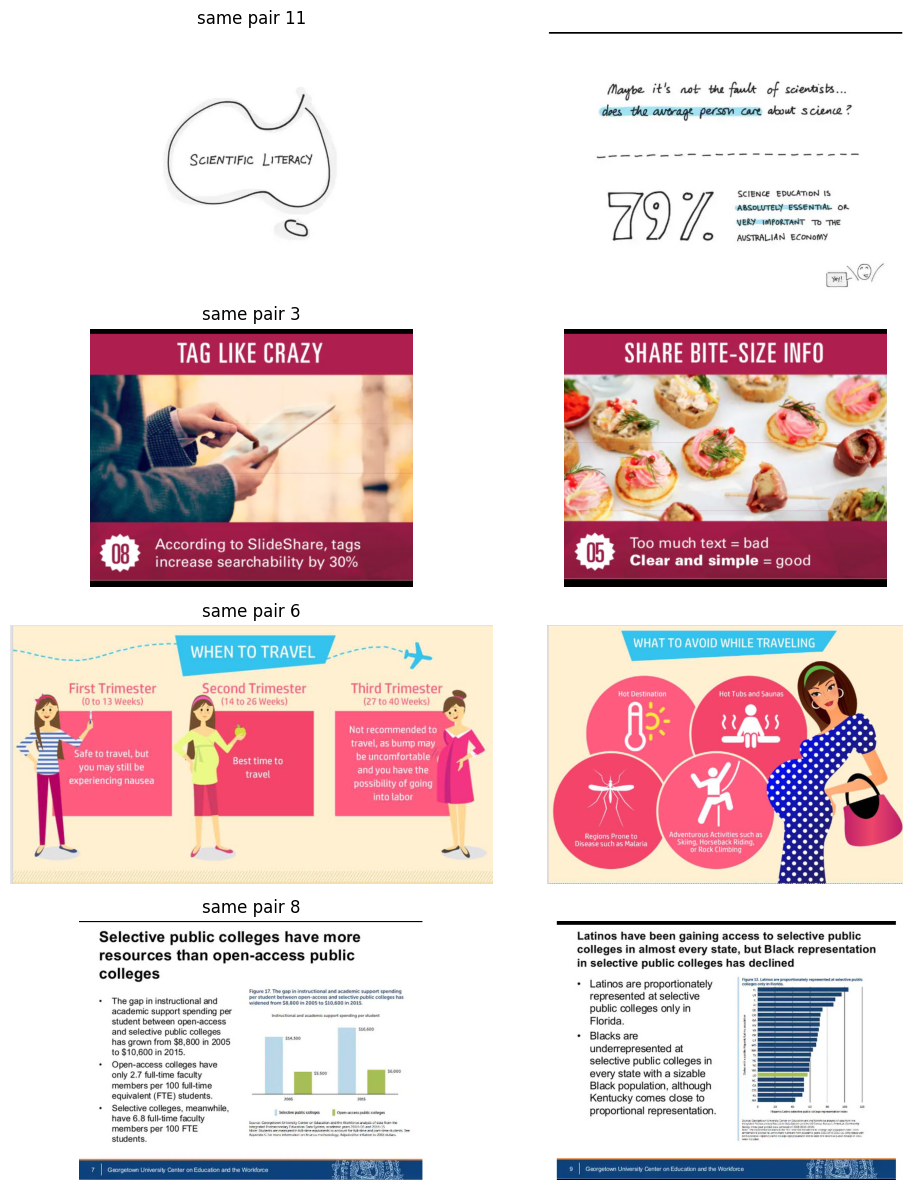

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Each item is a pair of image paths
image_pairs = [
    (
        "../data/test_dataset/same_style/11/184.png",
        "../data/test_dataset/same_style/11/186.png"
    ),
    (
        "../data/test_dataset/same_style/3/1.png",
        "../data/test_dataset/same_style/3/2.png"
    ),
    (
        "../data/test_dataset/same_style/6/Capture1.png",
        "../data/test_dataset/same_style/6/Capture3.png"
    ),
    (
        "../data/test_dataset/same_style/8/105.png",
        "../data/test_dataset/same_style/8/107.png"
    ),
]

labels = ["same pair 11", "same pair 3", "same pair 6", "same pair 8"]

# grid: one row per pair, two columns (left/right image)
fig, axes = plt.subplots(len(image_pairs), 2, figsize=(10, 12))

for row, (img_left, img_right) in enumerate(image_pairs):
    for col, img_path in enumerate([img_left, img_right]):
        ax = axes[row, col]
        img = mpimg.imread(img_path)
        ax.imshow(img)
        if col == 0:
            ax.set_title(labels[row])
        ax.axis("off")

plt.tight_layout()
plt.show()
